In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import tf, feedback, step_response, damp, step_info, rlocus
from math import sqrt, exp, pi

In [2]:
# Planta: G(s) = 10/(s*(s+1))
s = tf('s')
G = 10/(s*(s+1))

# Lazo abierto: Y_ol(s) = G(s)*1/s = 10/(s^2(s+1))
# Esta respuesta es inestable (creciente sin límite), pero podemos mostrarla:
time = np.linspace(0, 10, 1000)
T_ol, y_ol = step_response(G, T=time)

# Lazo cerrado realimentación unitaria: T(s) = G(s)/(1+G(s))
T_cl = feedback(G, 1)
T_cl_time, y_cl = step_response(T_cl, T=time)

# Ecuación estándar: s^2 + 2ξωn s + ωn^2
# Comparando:
# 2 ξ ωn = 1  y  ωn^2 = 10
wn = sqrt(10)
xi = 1/(2*wn)

# B.4) Tiempo de asentamiento (Ts)
# Aproximación para 2%: Ts ≈ 4/(ξ wn)
Ts = 4/(xi*wn)

# B.5) Sobrepaso (Mp)
# Mp = e^{(-ξπ/(sqrt(1-ξ²)))}
Mp = exp(-xi*pi/np.sqrt(1 - xi**2))

# B.6) Constante Kv
# Kv = lim s->0 sG(s) = 10
Kv = 10

----- Resultados SIN compensar (lazo cerrado actual) -----
xi (Coef. Amort.): 0.1581
wn (Freq. Natural): 3.1623 rad/s
Ts (asentamiento 2%): 8.0000 s
Mp (Sobrepaso): 60.47%
Kv: 10.00


C:\Users\Matzi\AppData\Local\Temp\ipykernel_46668\276066467.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


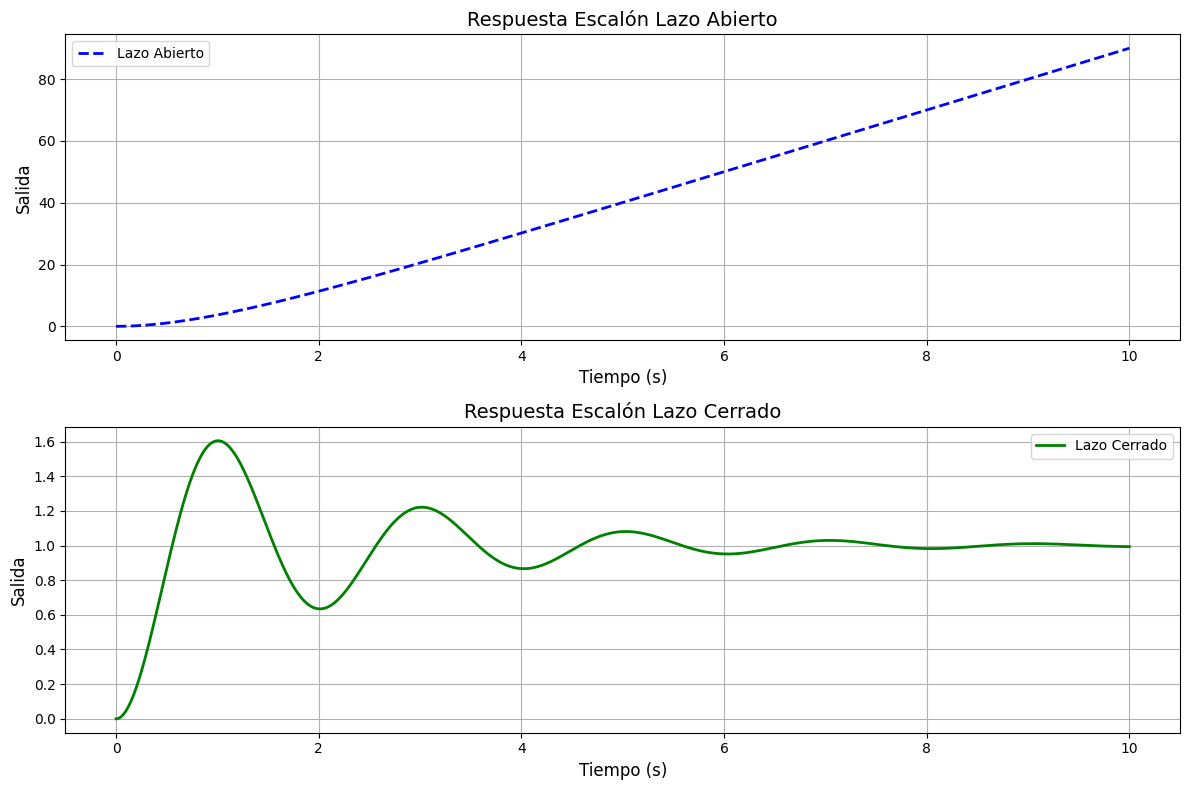

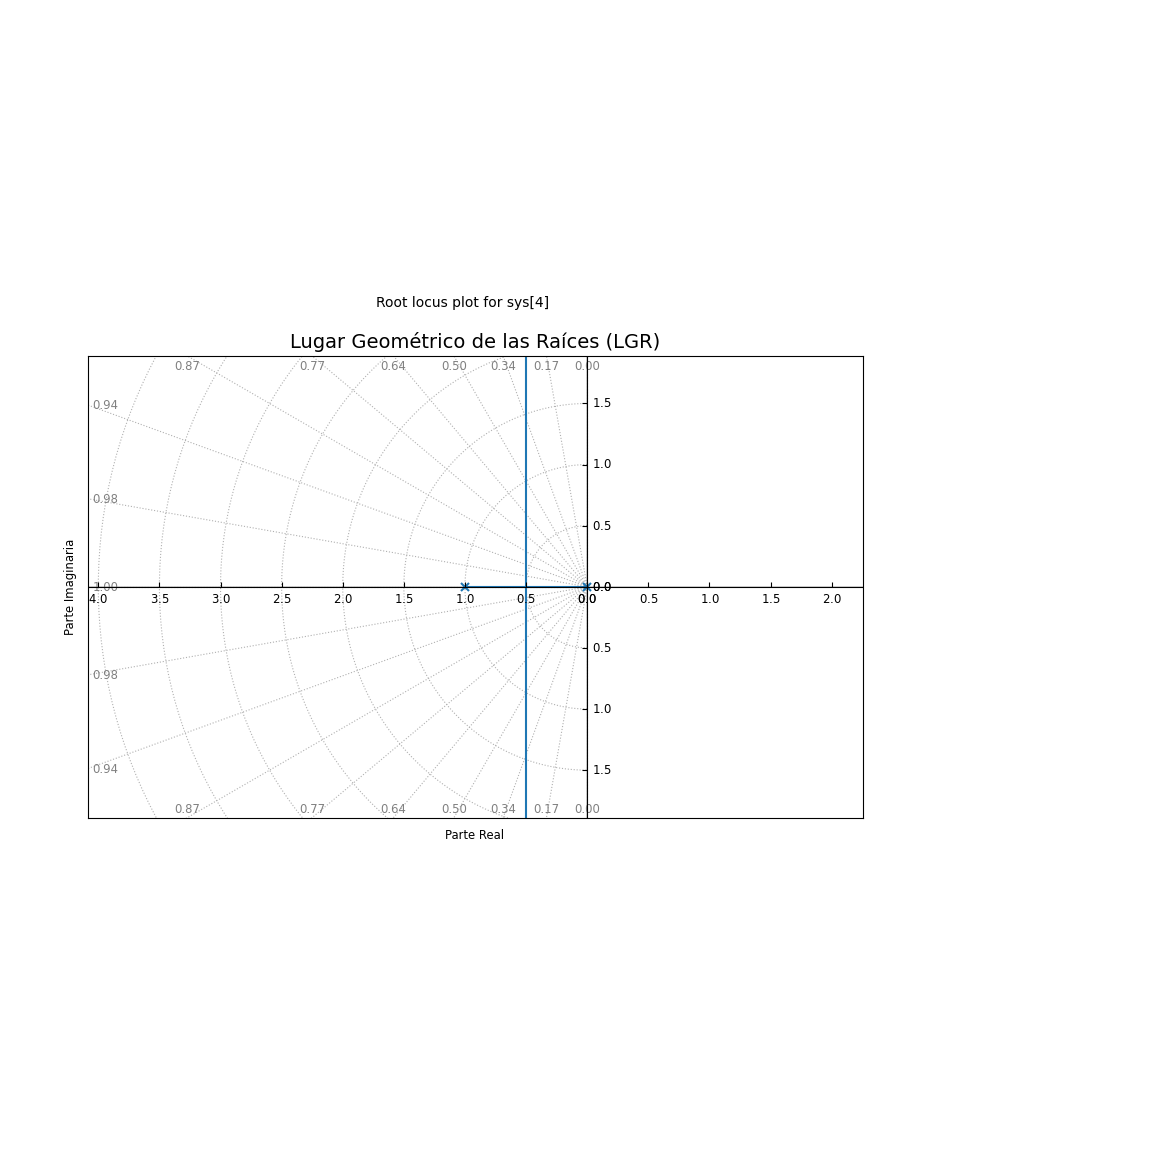

In [3]:
# Mostramos algunos resultados por pantalla
print("----- Resultados SIN compensar (lazo cerrado actual) -----")
print(f"xi (Coef. Amort.): {xi:.4f}")
print(f"wn (Freq. Natural): {wn:.4f} rad/s")
print(f"Ts (asentamiento 2%): {Ts:.4f} s")
print(f"Mp (Sobrepaso): {Mp*100:.2f}%")
print(f"Kv: {Kv:.2f}")

# Graficar respuestas escalón con estilo mejorado
fig_step = plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(T_ol, y_ol, label="Lazo Abierto", color='blue', linestyle='--', linewidth=2)
plt.title("Respuesta Escalón Lazo Abierto", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Salida", fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(T_cl_time, y_cl, label="Lazo Cerrado", color='green', linestyle='-', linewidth=2)
plt.title("Respuesta Escalón Lazo Cerrado", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Salida", fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()

fig_rlocus = plt.figure(figsize=(10, 6))
rlocus(G)
plt.title("Lugar Geométrico de las Raíces (LGR)", fontsize=14)
plt.xlabel("Parte Real", fontsize=12)
plt.ylabel("Parte Imaginaria", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

    Eigenvalue (pole)       Damping     Frequency
               -51.41             1         51.41
   -0.8554   +0.4219j        0.8969        0.9538
   -0.8554   -0.4219j        0.8969        0.9538
    Eigenvalue (pole)       Damping     Frequency
    -1.765    +2.968j        0.5112         3.453
    -1.765    -2.968j        0.5112         3.453
              -0.1406             1        0.1406
    Eigenvalue (pole)       Damping     Frequency
               -19.63             1         19.63
   -0.2084    +0.177j        0.7622        0.2734
   -0.2084    -0.177j        0.7622        0.2734
    Eigenvalue (pole)       Damping     Frequency
               -81.33             1         81.33
              -0.7591             1        0.7591
              -0.1242             1        0.1242
    Eigenvalue (pole)       Damping     Frequency
               -8.004             1         8.004
               -3.171             1         3.171
              -0.1133             1        0.1133


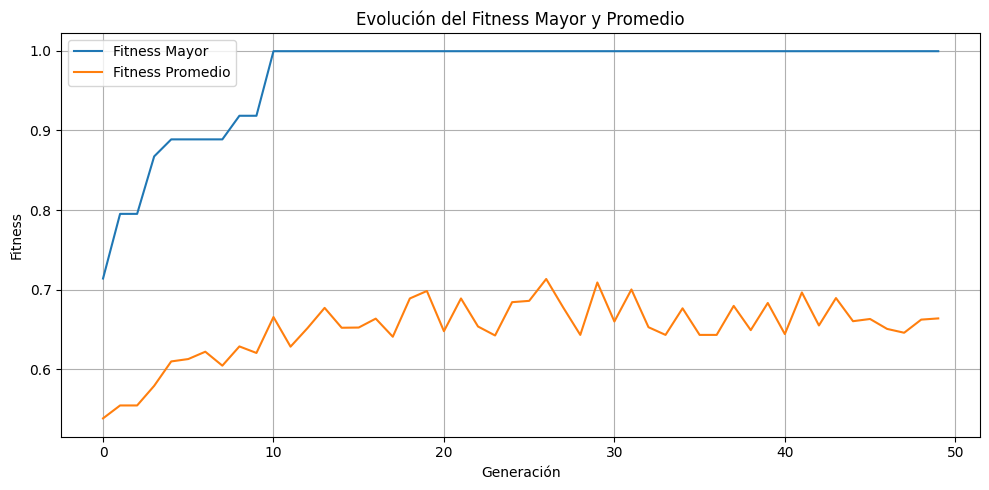

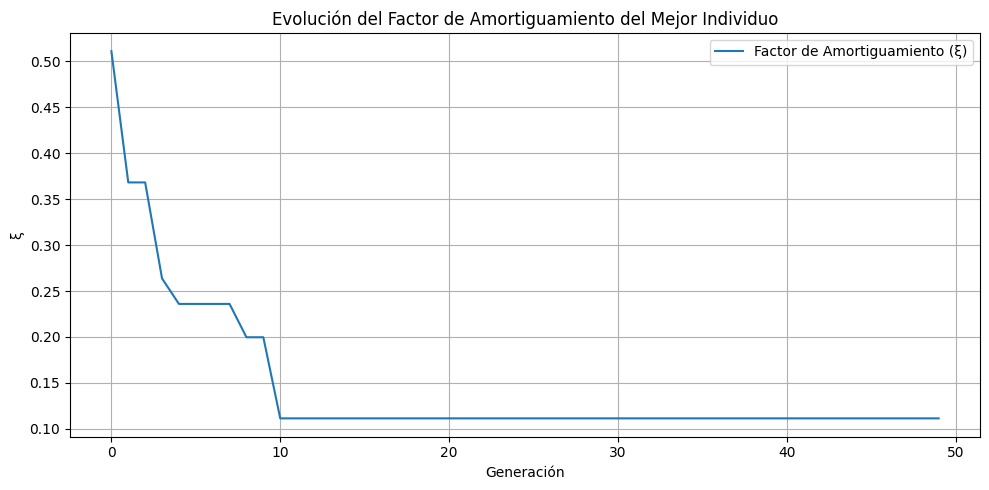

In [11]:
from control import tf, feedback

# Objetivo: por ejemplo, querer que el factor de amortiguamiento mejore respecto al original
xi_target = 0.7 * xi

# Rango de parámetros a sintonizar
Kp_min, Kp_max = 0.1, 10.0
Ti_min, Ti_max = 0.1, 10.0
Td_min, Td_max = 0.0, 5.0

# Cantidad de bits por parámetro
bits_Kp = 10
bits_Ti = 10
bits_Td = 10
total_bits = bits_Kp + bits_Ti + bits_Td

# Funciones de mapeo binario <-> real
def bin_to_real(bin_array, bits, min_val, max_val):
    val_int = 0
    for bit in bin_array:
        val_int = (val_int << 1) | bit
    # Escalado al rango
    return min_val + (max_val - min_val)*val_int/(2**bits - 1)

def decode_chromosome(chrom):
    Kp_bin = chrom[0:bits_Kp]
    Ti_bin = chrom[bits_Kp:bits_Kp+bits_Ti]
    Td_bin = chrom[bits_Kp+bits_Ti:bits_Kp+bits_Ti+bits_Td]
    Kp_val = bin_to_real(Kp_bin, bits_Kp, Kp_min, Kp_max)
    Ti_val = bin_to_real(Ti_bin, bits_Ti, Ti_min, Ti_max)
    Td_val = bin_to_real(Td_bin, bits_Td, Td_min, Td_max)
    return Kp_val, Ti_val, Td_val


def get_damping(Kp_val, Ti_val, Td_val):
    # Crear el controlador PID
    Gc = Kp_val + Kp_val/(Ti_val*s) + Kp_val*Td_val*s
    # Sistema en lazo cerrado
    T_cl = feedback(G*Gc, 1)
    # Obtener el factor de amortiguamiento
    _, xi, _ = damp(T_cl)
    return xi[0]  # Devolver el primer factor de amortiguamiento
    

# Función de aptitud (Fitness)
# Más cerca del objetivo xi_target, mayor es el fitness
def fitness(chrom):
    Kp_val, Ti_val, Td_val = decode_chromosome(chrom)
    xi_new = get_damping(Kp_val, Ti_val, Td_val)
    # Fitness: más cerca a xi_target, más cerca a 1
    return 1/(1 + abs(xi_new - xi_target))



#------------------------------------------------------------
# Parámetros del Algoritmo Genético
#------------------------------------------------------------
N = 20 # Tamaño de población
generations = 50     # Número de generaciones
Pm = 0.4             # Probabilidad % de mutación por gen
top_count = 5       # Número de mejores individuos a conservar y cruzar

# Inicialización de la población
population = np.random.randint(0,2,(N,total_bits))

best_history = []      # Almacena el fitness mayor por generación
avg_history = []       # Almacena el fitness promedio por generación
min_history = []       # Almacena el fitness menor por generación
xi_history = []        # Almacena el factor de amortiguamiento (ξ) del mejor individuo

def evaluate_population(pop):
    return np.array([fitness(ind) for ind in pop])

def crossover(parent1, parent2):
    # Cruce en un punto
    point = np.random.randint(1,total_bits)
    child1 = np.concatenate((parent1[:point], parent2[point:]))
    child2 = np.concatenate((parent2[:point], parent1[point:]))
    return child1, child2

def mutate(chrom):
    for i in range(total_bits):
        if np.random.rand() < Pm:
            chrom[i] = 1 - chrom[i]  # flip bit
    return chrom

pop = population

for gen in range(generations):
    fvals = evaluate_population(pop)
    # Ordenar por fitness de mayor a menor (queremos maximizar fitness)
    idx_sorted = np.argsort(-fvals)  # argsort negativo ordena descendentemente
    sorted_pop = pop[idx_sorted]
    sorted_f = fvals[idx_sorted]
    
    # Tomar valores de fitness mayor, menor, promedio:
    best_f = sorted_f[0]
    avg_f = np.mean(sorted_f)
    min_f = sorted_f[-1]
    best_ind = sorted_pop[0]
    Kp_val, Ti_val, Td_val = decode_chromosome(best_ind)
    best_xi = get_damping(Kp_val, Ti_val, Td_val)
    
    best_history.append(best_f)
    avg_history.append(avg_f)
    min_history.append(min_f)
    xi_history.append(best_xi)
    
    # Mantener los top_count mejores directamente (elite)
    elites = sorted_pop[:top_count]
    # Generar hijos cruzando entre estos top_count
    new_pop = []
    # Conservar los elites directamente
    new_pop.extend(elites)
    
    # Rellenamos la población hasta N
    while len(new_pop) < N:
        p1, p2 = np.random.choice(top_count, 2, replace=False)
        parent1 = elites[p1]
        parent2 = elites[p2]
        c1, c2 = crossover(parent1, parent2)
        # Mutar
        c1 = mutate(c1)
        if len(new_pop) < N:
            new_pop.append(c1)
        c2 = mutate(c2)
        if len(new_pop) < N:
            new_pop.append(c2)
    
    pop = np.array(new_pop)

# Al finalizar
fvals = evaluate_population(pop)
idx_sorted = np.argsort(-fvals)
sorted_pop = pop[idx_sorted]
sorted_f = fvals[idx_sorted]

best_ind = sorted_pop[0]
best_fit = sorted_f[0]
Kp_val, Ti_val, Td_val = decode_chromosome(best_ind)

print("----- Resultados finales del AG -----")
print("Mejor individuo encontrado:")
print(f"Kp_val = {Kp_val:.4f}, Ti_val = {Ti_val:.4f}, Td_val = {Td_val:.4f}")
print(f"Fitness = {best_fit:.4f}")
print(f"Factor de amortiguamiento (xi) del mejor individuo: {xi_history[-1]:.4f}")

# Graficar evolución del Fitness (mayor y promedio)
plt.figure(figsize=(10,5))
plt.plot(best_history, label="Fitness Mayor")
plt.plot(avg_history, label="Fitness Promedio")
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Evolución del Fitness Mayor y Promedio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graficar evolución del factor de amortiguamiento
plt.figure(figsize=(10,5))
plt.plot(xi_history, label="Factor de Amortiguamiento (ξ)")
plt.xlabel("Generación")
plt.ylabel("ξ")
plt.title("Evolución del Factor de Amortiguamiento del Mejor Individuo")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


----- Sistema sin compensar -----
xi: 0.1581
wn: -0.5000+3.1225j rad/s
Ts: 7.3842 s
Mp: 60.26%
Kv: 10

----- Sistema con PID compensado -----
PID Encontrado: Kp=6.1677, Ti=6.3129, Td=0.0147
xi: 0.1114
wn: -0.8726+7.7871j rad/s
Ts: 4.4886 s
Mp: 71.13%
Kv: inf


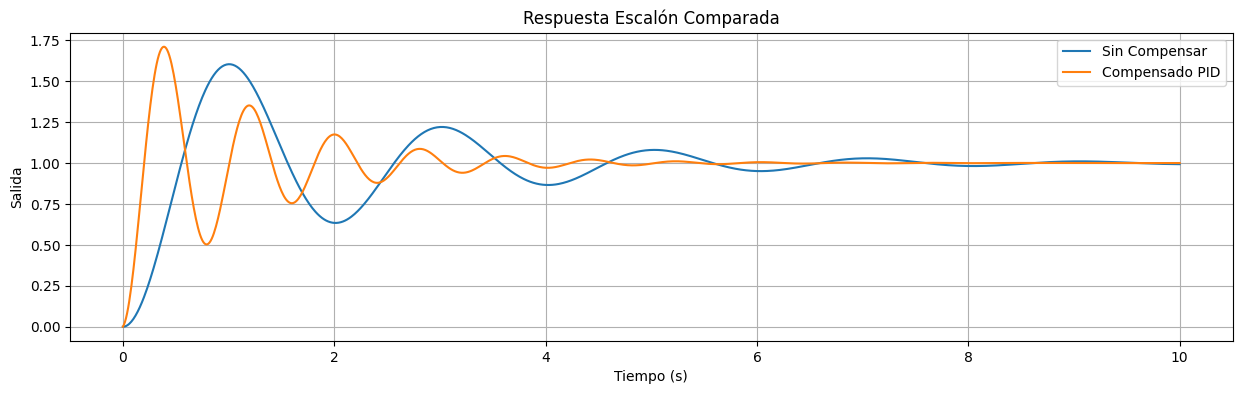

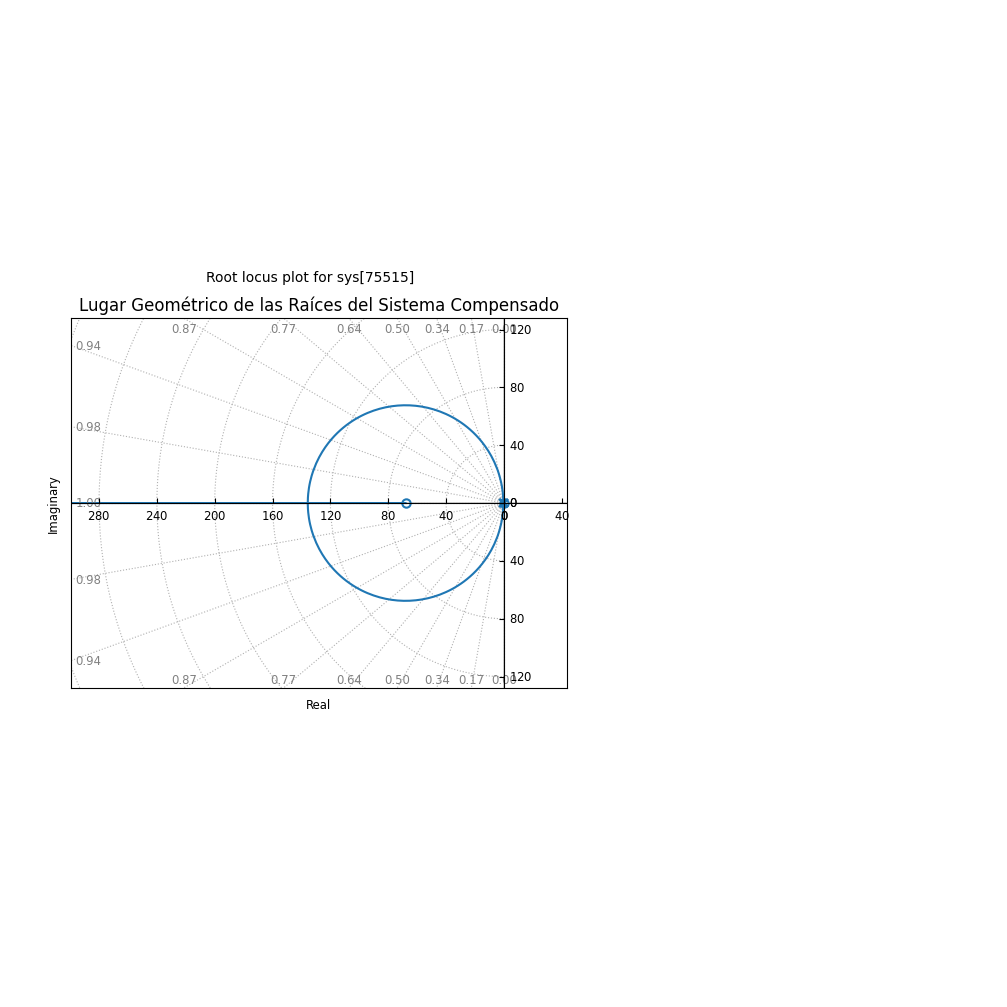

In [12]:
Kp_val == 6.1677, Ti_val == 6.3129, Td_val == 0.0147

# Construimos el compensador PID:
Gc = Kp_val*(1 + 1/(Ti_val*s) + Td_val*s)

# Sistema compensado en lazo cerrado:
T_comp = feedback(Gc*G, 1)

# Respuesta escalón comparada:
t = np.linspace(0,10,1000)  # rango de tiempo
t_cl, y_cl = step_response(feedback(G,1), T=t)  # sin compensar
t_comp_, y_comp = step_response(T_comp, T=t)    # con PID compensado

# Cálculo de parámetros sin compensar:
poles_no_comp, zeta_no_comp, wn_no_comp = damp(feedback(G,1), doprint=False)
xi_no_comp = np.min(zeta_no_comp)
wn_no_comp_val = wn_no_comp[np.argmin(zeta_no_comp)]
# Tiempo de asentamiento y sobrepaso (sin compensar)
info_no_comp = step_info(feedback(G,1))
Ts_no_comp = info_no_comp['SettlingTime']   # tiempo de asentamiento approx al 2%
Mp_no_comp = (info_no_comp['Overshoot'])     # sobrepaso en %
# Kv sin compensar:
# Kv = lim s->0 sG(s) = 10
Kv_no_comp = 10

# Cálculo de parámetros compensados:
poles_comp, zeta_comp, wn_comp = damp(T_comp, doprint=False)
xi_comp = np.min(zeta_comp)
wn_comp_val = wn_comp[np.argmin(zeta_comp)]

info_comp = step_info(T_comp)
Ts_comp = info_comp['SettlingTime']
Mp_comp = info_comp['Overshoot']  # sobrepaso en %

# Constante Kv compensada:
# Kv = lim s->0 s * Gc(s)*G(s)
# Evaluamos GcG en s=0:
num_gc, den_gc = (Gc*G).num[0][0], (Gc*G).den[0][0]
num_val = np.polyval(num_gc,0)
den_val = np.polyval(den_gc,0)
Kv_comp = num_val/den_val if den_val!=0 else np.inf

# Mostrar resultados
print("----- Sistema sin compensar -----")
print(f"xi: {xi_no_comp:.4f}")
print(f"wn: {wn_no_comp_val:.4f} rad/s")
print(f"Ts: {Ts_no_comp:.4f} s")
print(f"Mp: {Mp_no_comp:.2f}%")
print(f"Kv: {Kv_no_comp}")

print("\n----- Sistema con PID compensado -----")
print(f"PID Encontrado: Kp={Kp_val:.4f}, Ti={Ti_val:.4f}, Td={Td_val:.4f}")
print(f"xi: {xi_comp:.4f}")
print(f"wn: {wn_comp_val:.4f} rad/s")
print(f"Ts: {Ts_comp:.4f} s")
print(f"Mp: {Mp_comp:.2f}%")
print(f"Kv: {Kv_comp:.2f}")

# Graficar respuestas escalón

plt.figure(figsize=(15,4))
plt.plot(t_cl, y_cl, label="Sin Compensar")
plt.plot(t_comp_, y_comp, label="Compensado PID")
plt.title("Respuesta Escalón Comparada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.grid(True)
plt.legend()

# Graficar lugar geométrico de las raíces con compensador:
plt.figure()
rlocus(Gc*G)
plt.title("Lugar Geométrico de las Raíces del Sistema Compensado")
plt.grid(True)

plt.show()